# Projet Api Immo Lille — Analyse & Modélisation

## 📜 Objectifs du projet

L’objectif de ce projet est d’analyser un jeu de données de transactions immobilières à Lille en 2022,  
afin de comprendre quels facteurs influencent le prix au mètre carré des logements.  

Nous allons :  
- Charger et filtrer les données.  
- Nettoyer et préparer le dataset pour la modélisation.  
- Séparer maisons et appartements pour des analyses distinctes.  
- Construire plusieurs modèles de régression pour prédire le prix au m².  
- Comparer les performances des modèles pour choisir le meilleur.

---

## 1. Chargement des bibliothèques nécessaires

Avant toute chose, nous importons les bibliothèques indispensables pour :  
- Manipuler les données (pandas, numpy).  
- Visualiser les données (matplotlib, seaborn).  
- Construire, évaluer et optimiser les modèles (scikit-learn, xgboost).  
- Sauvegarder les modèles entraînés (joblib).

In [1]:
#import utile pour le projet machine learning 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest
from sklearn.compose import ColumnTransformer

import os 

## 2. Chargement et filtrage initial des données

Nous chargeons ici le fichier CSV contenant les transactions.  

Pour garder une analyse ciblée et homogène,  
nous ne conservons que les logements ayant exactement 4 pièces principales.  

Nous sélectionnons aussi les colonnes pertinentes pour notre étude :  
surface bâtie, type de logement, surface du terrain, nombre de lots, et valeur foncière.


In [2]:
df = pd.read_csv("../data/lille_2022.csv")

# Ne garder que les logements à 4 pièces
df = df[df["Nombre pieces principales"] == 4]

# Sélection des colonnes utiles
cols = [
    "Surface reelle bati",
    "Nombre pieces principales",
    "Type local",
    "Surface terrain",
    "Nombre de lots",
    "Valeur fonciere",
]
df = df[cols]
display(df)


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
18,165.0,4.0,Maison,121.0,0,305000.0
23,92.0,4.0,Appartement,NaN,1,367000.0
26,70.0,4.0,Appartement,NaN,2,170000.0
58,105.0,4.0,Appartement,NaN,2,355300.0
62,120.0,4.0,Appartement,NaN,1,472500.0
...,...,...,...,...,...,...
11316,103.0,4.0,Appartement,NaN,2,381500.0
11328,117.0,4.0,Appartement,NaN,2,627000.0
11351,78.0,4.0,Appartement,NaN,1,174000.0
11352,72.0,4.0,Maison,278.0,0,200000.0


## 3. Séparation en maisons et appartements & nettoyage

On divise le dataset en deux sous-ensembles : maisons et appartements,  
car les caractéristiques et comportements de prix peuvent différer.  

Ensuite, on gère les valeurs manquantes, notamment dans la surface terrain :  
- Pour les maisons, on remplace les valeurs manquantes par 0 (absence de terrain).  
- Pour les appartements aussi, la surface terrain est souvent nulle, on fait de même.

Cela évite de perdre trop d’observations tout en gardant la cohérence.


In [3]:
# Séparer maisons et appartements
df_maisons = df[df['Type local'].str.lower().str.contains('maison')].copy()
df_apparts = df[df['Type local'].str.lower().str.contains('appartement')].copy()

# Remplacer les valeurs manquantes dans la surface terrain par 0
median_terrain = df_maisons['Surface terrain'].median()
df_maisons['Surface terrain'] = df_maisons['Surface terrain'].fillna(median_terrain)
df_apparts['Surface terrain'] = df_apparts['Surface terrain'].fillna(0)

print("Maisons:")
display(df_maisons.head())

print("\nAppartements:")
display(df_apparts.head())



Maisons:


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
18,165.0,4.0,Maison,121.0,0,305000.0
65,64.0,4.0,Maison,127.0,0,226900.0
161,70.0,4.0,Maison,192.0,0,205890.0
168,62.0,4.0,Maison,96.0,0,159500.0
176,72.0,4.0,Maison,135.0,0,259900.0



Appartements:


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
23,92.0,4.0,Appartement,0.0,1,367000.0
26,70.0,4.0,Appartement,0.0,2,170000.0
58,105.0,4.0,Appartement,0.0,2,355300.0
62,120.0,4.0,Appartement,0.0,1,472500.0
113,71.0,4.0,Appartement,0.0,1,229900.0


In [4]:
print("Maisons:")
display(df_maisons)

print("\nAppartements:")
display(df_apparts)

Maisons:


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
18,165.0,4.0,Maison,121.0,0,305000.0
65,64.0,4.0,Maison,127.0,0,226900.0
161,70.0,4.0,Maison,192.0,0,205890.0
168,62.0,4.0,Maison,96.0,0,159500.0
176,72.0,4.0,Maison,135.0,0,259900.0
...,...,...,...,...,...,...
11091,120.0,4.0,Maison,100.0,0,320000.0
11129,110.0,4.0,Maison,225.0,0,412000.0
11235,86.0,4.0,Maison,171.0,0,230000.0
11352,72.0,4.0,Maison,278.0,0,200000.0



Appartements:


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
23,92.0,4.0,Appartement,0.0,1,367000.0
26,70.0,4.0,Appartement,0.0,2,170000.0
58,105.0,4.0,Appartement,0.0,2,355300.0
62,120.0,4.0,Appartement,0.0,1,472500.0
113,71.0,4.0,Appartement,0.0,1,229900.0
...,...,...,...,...,...,...
11267,112.0,4.0,Appartement,0.0,2,500000.0
11271,81.0,4.0,Appartement,0.0,1,173250.0
11316,103.0,4.0,Appartement,0.0,2,381500.0
11328,117.0,4.0,Appartement,0.0,2,627000.0


## 4. Vérification des valeurs manquantes et des zéros

Il est important de vérifier la présence de données manquantes ou aberrantes (zéros)  
dans les colonnes numériques, car cela peut fausser les modèles.

Cette fonction affiche, pour chaque colonne numérique, le nombre de valeurs nulles et de zéros.


In [5]:
def detect_nan_and_zeros(df: pd.DataFrame) -> pd.DataFrame:
    num_cols = df.select_dtypes(include='number').columns
    results = []
    for col in num_cols:
        n_nan = df[col].isna().sum()
        n_zero = (df[col] == 0).sum()
        results.append({"column": col, "n_nan": n_nan, "n_zero": n_zero})
    return pd.DataFrame(results)

print("Maisons:")
display(detect_nan_and_zeros(df_maisons))

print("\nAppartements:")
display(detect_nan_and_zeros(df_apparts))


Maisons:


,column,n_nan,n_zero
0,Surface reelle bati,0,0
1,Nombre pieces principales,0,0
2,Surface terrain,0,0
3,Nombre de lots,0,340
4,Valeur fonciere,0,0



Appartements:


,column,n_nan,n_zero
0,Surface reelle bati,0,0
1,Nombre pieces principales,0,0
2,Surface terrain,0,386
3,Nombre de lots,0,49
4,Valeur fonciere,0,0


## 5. Calcul du prix au m²

Pour mieux comparer les biens immobiliers, on calcule le prix au mètre carré  
en divisant la valeur foncière par la surface bâtie réelle.

Cette variable cible (`prix_m2`) sera prédite par nos modèles.
 prix au m²

In [6]:
df_maisons['prix_m2'] = df_maisons['Valeur fonciere'] / df_maisons['Surface reelle bati']
df_apparts['prix_m2'] = df_apparts['Valeur fonciere'] / df_apparts['Surface reelle bati']


## 6. Analyse exploratoire : distribution et détection des valeurs aberrantes

Avant de modéliser, on visualise la distribution du prix au m²,  
avec des boxplots pour détecter les valeurs extrêmes (outliers).

On trace également les histogrammes avec estimation de densité (KDE)  
pour observer la répartition du prix au m² dans chaque catégorie.


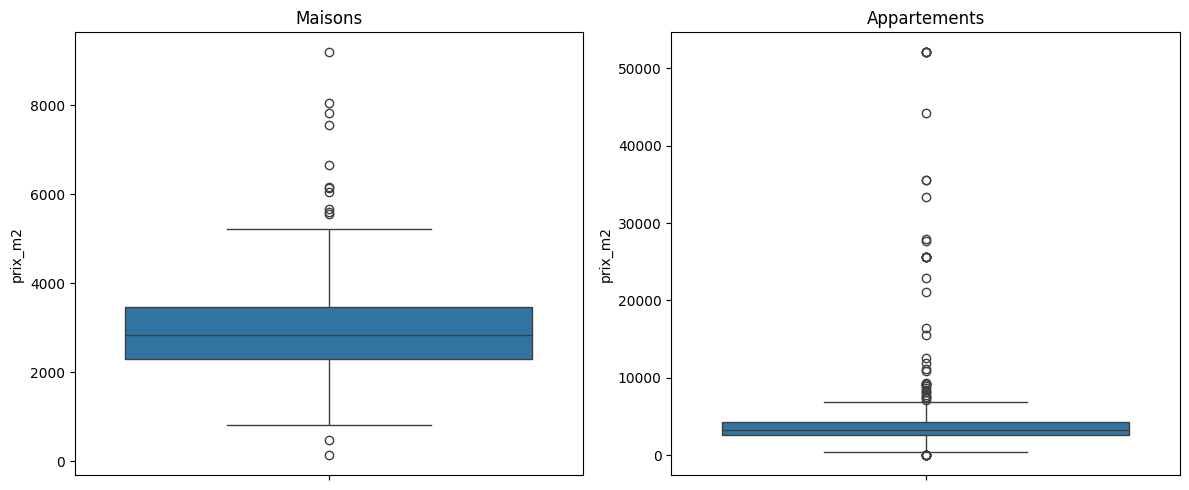

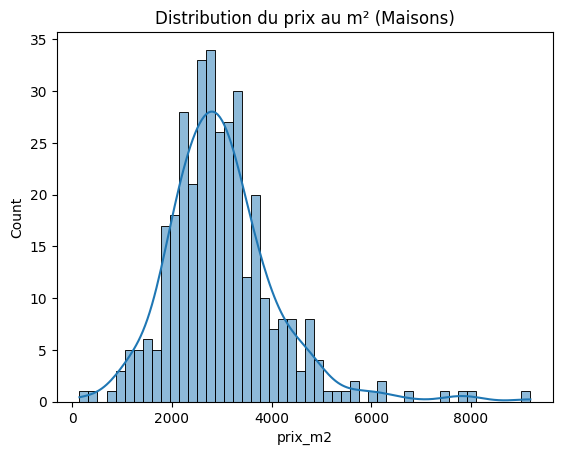

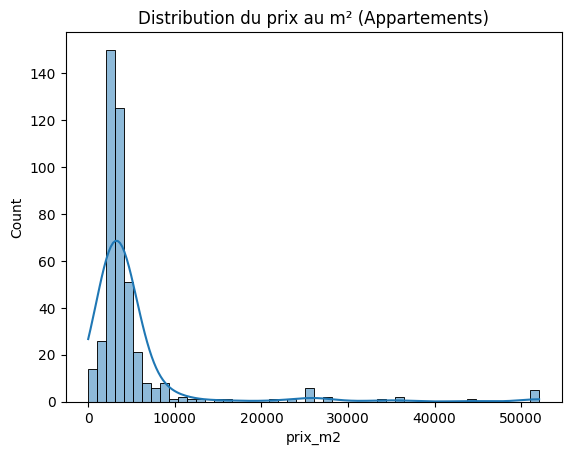

In [7]:
# Boxplots prix/m2
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df_maisons, y='prix_m2', ax=ax[0]).set_title('Maisons')
sns.boxplot(data=df_apparts, y='prix_m2', ax=ax[1]).set_title('Appartements')
plt.tight_layout()
plt.show()

# Distribution
sns.histplot(df_maisons['prix_m2'], bins=50, kde=True)
plt.title('Distribution du prix au m² (Maisons)')
plt.show()

sns.histplot(df_apparts['prix_m2'], bins=50, kde=True)
plt.title('Distribution du prix au m² (Appartements)')
plt.show()

## 7. Détection et suppression des valeurs aberrantes

Les outliers peuvent fortement dégrader la qualité des modèles.

On utilise la règle classique de l’IQR (Interquartile Range) pour détecter  
et exclure les valeurs extrêmes dans plusieurs variables clés.

Cette étape garantit que les données sont plus homogènes et fiables.


In [8]:
def detect_outliers(df, column):
    Q1, Q3 = df[column].quantile(0.25), df[column].quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return lb, ub

# Nettoyage pour les maisons
for col in ['prix_m2', 'Surface reelle bati', 'Surface terrain']:
    lb, ub = detect_outliers(df_maisons, col)
    df_maisons = df_maisons[(df_maisons[col] >= lb) & (df_maisons[col] <= ub)]

# Nettoyage pour les appartements
for col in ['prix_m2', 'Surface reelle bati']:
    lb, ub = detect_outliers(df_apparts, col)
    df_apparts = df_apparts[(df_apparts[col] >= lb) & (df_apparts[col] <= ub)]

## 8 Visualisation post-nettoyage : qualité des données et relations

Après le nettoyage des données, il est important de vérifier la qualité des données nettoyées avec des visualisations adaptées.
Cela nous permet de :

  - Valider que les valeurs aberrantes ont bien été supprimées (boxplots et histogrammes).
  - Observer la distribution des variables cibles après nettoyage.
  - Vérifier les relations entre variables numériques via une heatmap de corrélation.
  - Visualiser la relation entre les valeurs prédites et observées (scatter plot) sera fait plus tard lors de l’évaluation des modèles.

### Visualisations pour les maisons

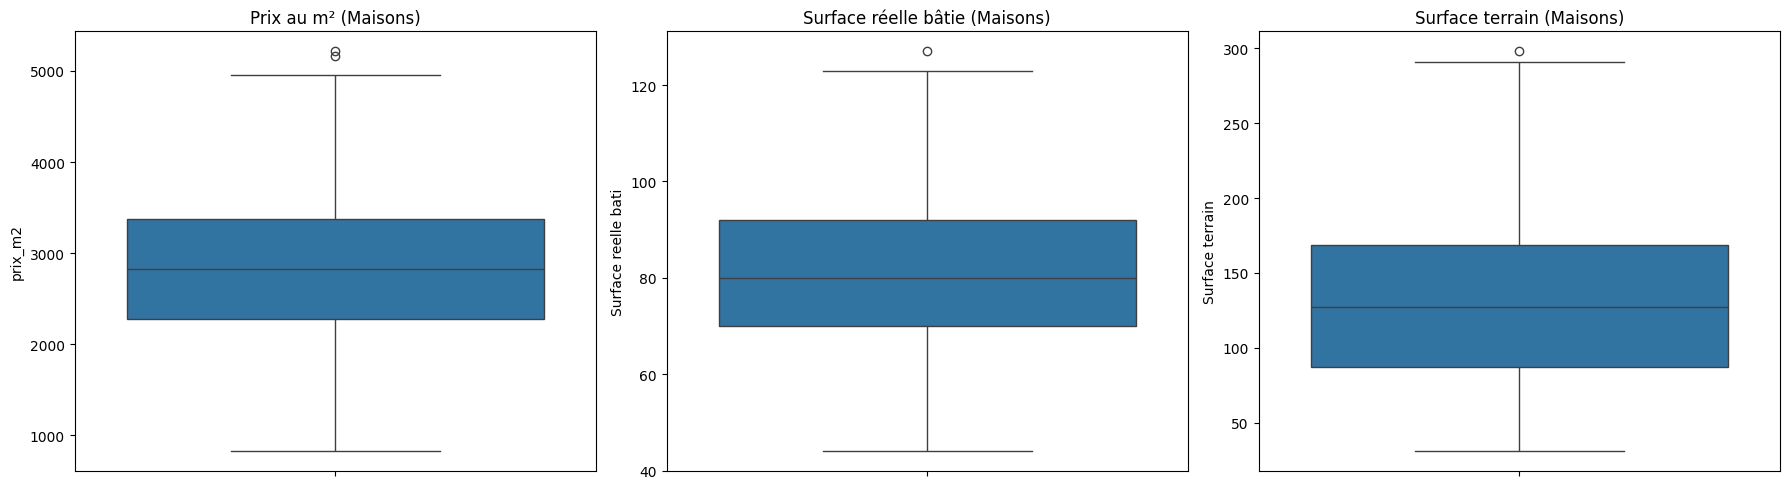

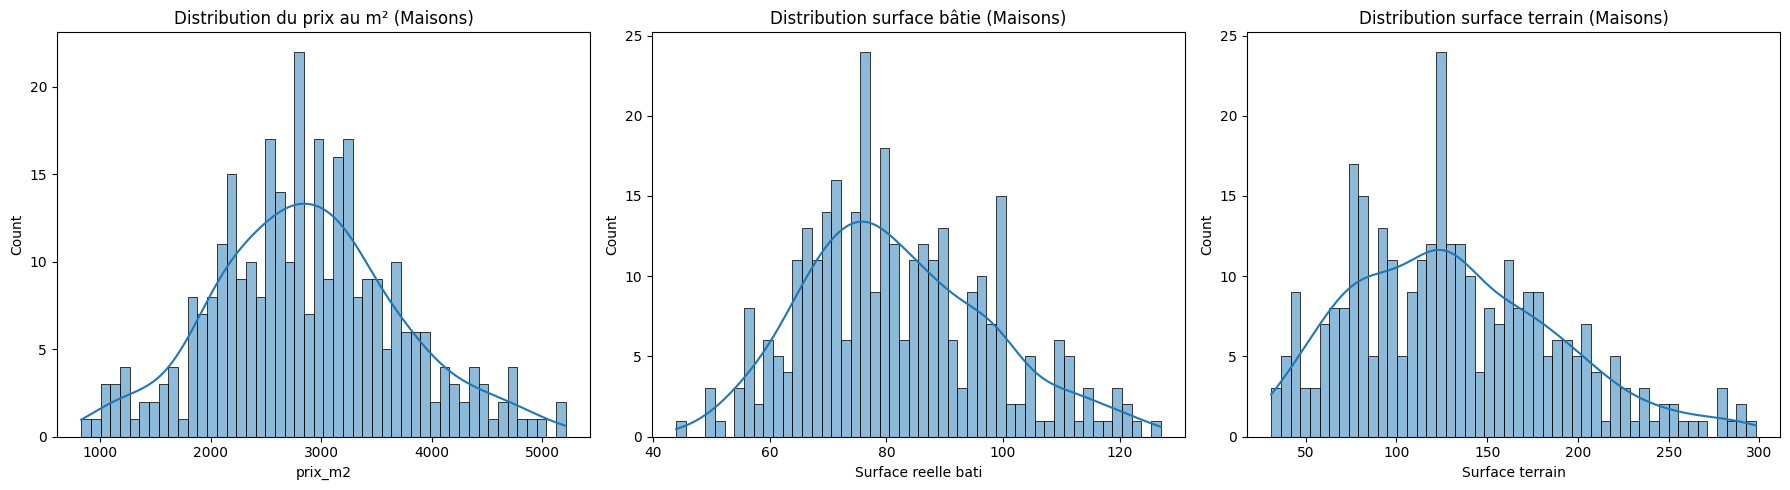

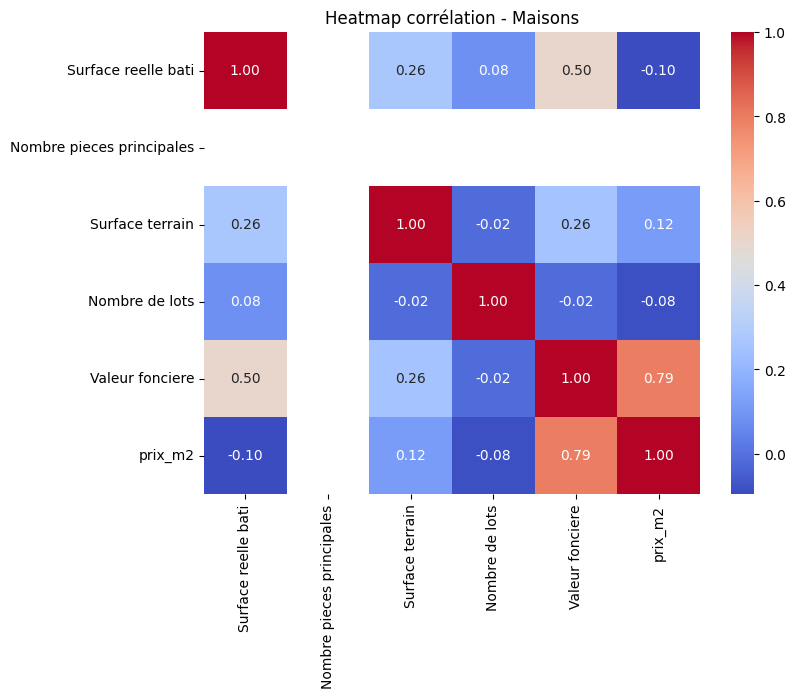

In [9]:
# Boxplots post-nettoyage pour les maisons
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df_maisons, y='prix_m2', ax=ax[0]).set_title('Prix au m² (Maisons)')
sns.boxplot(data=df_maisons, y='Surface reelle bati', ax=ax[1]).set_title('Surface réelle bâtie (Maisons)')
sns.boxplot(data=df_maisons, y='Surface terrain', ax=ax[2]).set_title('Surface terrain (Maisons)')
plt.tight_layout()
plt.show()

# Histogrammes post-nettoyage pour les maisons
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_maisons['prix_m2'], bins=50, kde=True, ax=ax[0])
ax[0].set_title('Distribution du prix au m² (Maisons)')
sns.histplot(df_maisons['Surface reelle bati'], bins=50, kde=True, ax=ax[1])
ax[1].set_title('Distribution surface bâtie (Maisons)')
sns.histplot(df_maisons['Surface terrain'], bins=50, kde=True, ax=ax[2])
ax[2].set_title('Distribution surface terrain (Maisons)')
plt.tight_layout()
plt.show()

# Heatmap de corrélation pour les maisons (seulement colonnes numériques)
plt.figure(figsize=(8,6))
corr_maisons = df_maisons.select_dtypes(include=np.number).corr()
sns.heatmap(corr_maisons, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap corrélation - Maisons')
plt.show()

### Visualisations pour les appartements

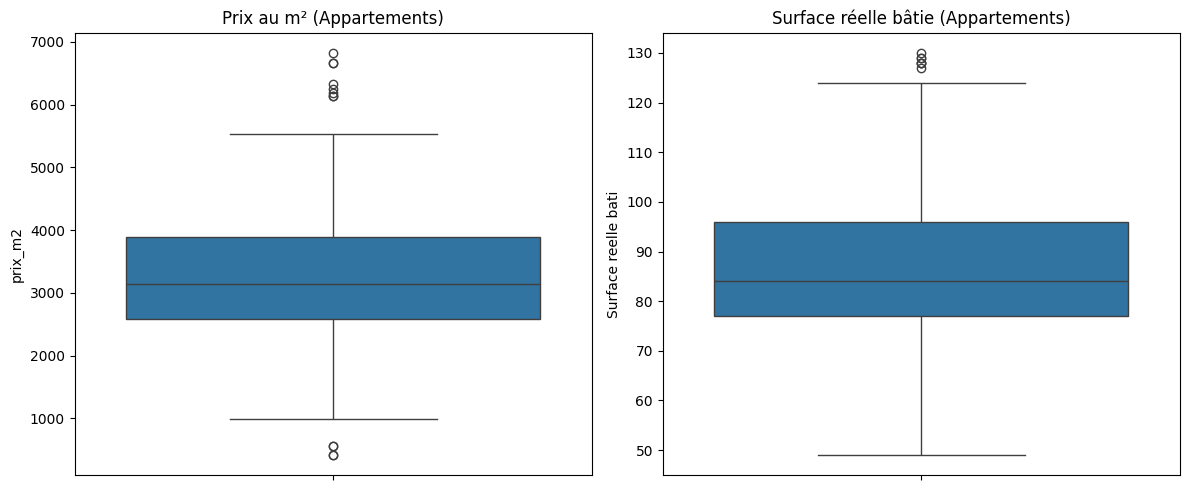

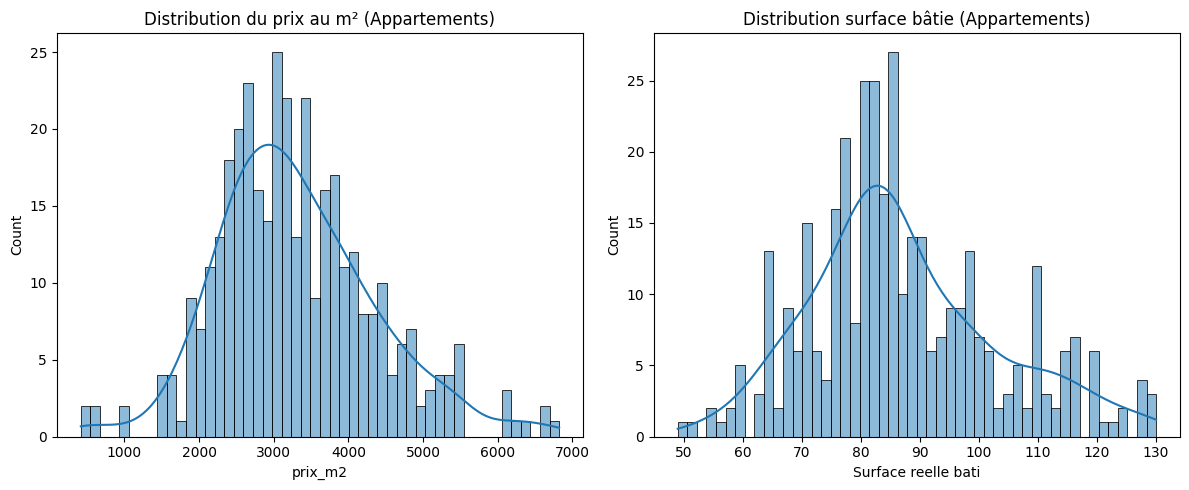

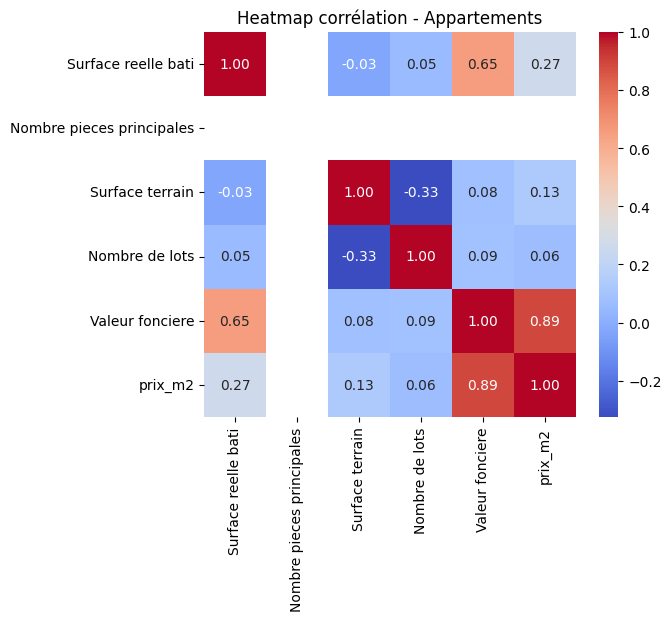

In [10]:
# Boxplots post-nettoyage pour les appartements
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_apparts, y='prix_m2', ax=ax[0]).set_title('Prix au m² (Appartements)')
sns.boxplot(data=df_apparts, y='Surface reelle bati', ax=ax[1]).set_title('Surface réelle bâtie (Appartements)')
plt.tight_layout()
plt.show()

# Histogrammes post-nettoyage pour les appartements
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_apparts['prix_m2'], bins=50, kde=True, ax=ax[0])
ax[0].set_title('Distribution du prix au m² (Appartements)')
sns.histplot(df_apparts['Surface reelle bati'], bins=50, kde=True, ax=ax[1])
ax[1].set_title('Distribution surface bâtie (Appartements)')
plt.tight_layout()
plt.show()

# Heatmap de corrélation pour les appartements (colonnes numériques uniquement)
plt.figure(figsize=(6,5))
corr_apparts = df_apparts.select_dtypes(include=np.number).corr()
sns.heatmap(corr_apparts, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap corrélation - Appartements')
plt.show()

In [11]:
display(df_maisons)
display(df_apparts)

,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere,prix_m2
65,64.0,4.0,Maison,127.0,0,226900.0,3545.312500
161,70.0,4.0,Maison,192.0,0,205890.0,2941.285714
168,62.0,4.0,Maison,96.0,0,159500.0,2572.580645
176,72.0,4.0,Maison,135.0,0,259900.0,3609.722222
231,80.0,4.0,Maison,182.0,0,220000.0,2750.000000
...,...,...,...,...,...,...,...
11091,120.0,4.0,Maison,100.0,0,320000.0,2666.666667
11129,110.0,4.0,Maison,225.0,0,412000.0,3745.454545
11235,86.0,4.0,Maison,171.0,0,230000.0,2674.418605
11352,72.0,4.0,Maison,278.0,0,200000.0,2777.777778


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere,prix_m2
23,92.0,4.0,Appartement,0.0,1,367000.0,3989.130435
26,70.0,4.0,Appartement,0.0,2,170000.0,2428.571429
58,105.0,4.0,Appartement,0.0,2,355300.0,3383.809524
62,120.0,4.0,Appartement,0.0,1,472500.0,3937.500000
113,71.0,4.0,Appartement,0.0,1,229900.0,3238.028169
...,...,...,...,...,...,...,...
11267,112.0,4.0,Appartement,0.0,2,500000.0,4464.285714
11271,81.0,4.0,Appartement,0.0,1,173250.0,2138.888889
11316,103.0,4.0,Appartement,0.0,2,381500.0,3703.883495
11328,117.0,4.0,Appartement,0.0,2,627000.0,5358.974359


### 9. Fonction d’entraînement et d’évaluation des modèles (`run_all_models`)

Cette fonction entraîne et évalue automatiquement plusieurs modèles de machine learning pour la prédiction du prix au m².

#### 🔧 Étapes réalisées :

- **Préparation des données** :
    - Encodage OneHot pour les variables catégorielles.
    - Standardisation des variables numériques.
- **Séparation des données** : split en jeu d'entraînement et de test.
- **Entraînement de plusieurs modèles** :
    - Régression Linéaire (avec sélection de features par SelectKBest).
    - Arbre de Décision.
    - Forêt Aléatoire.
    - XGBoost.        
- **Recherche des meilleurs hyperparamètres** : via `GridSearchCV` avec validation croisée.    
- **Évaluation des performances** :    
    - MSE (erreur quadratique moyenne)
    - MAE (erreur absolue moyenne)
    - R² (coefficient de détermination)
- **Comparaison graphique** des modèles sur ces métriques.
- **Retour** :
    - Un dictionnaire `results` contenant les scores des modèles testés.
    - Un dictionnaire `best_pipelines` ne contenant que le **meilleur pipeline** (modèle + preprocessing) pour chaque type de logement (maison/appartement), afin d’être sauvegardé ensuite
        
> Cette fonction permet ainsi une évaluation rigoureuse et la sélection automatisée des meilleurs modèles prêts à l’usage ou à la mise en production.


In [12]:
def run_all_models(df, target="prix_m2", title="Comparaison des modèles"):
    """
    Exécute plusieurs modèles de régression sur un ensemble de données donné, 
    effectue une validation croisée et affiche les performances des modèles 
    ainsi que les importances des caractéristiques pour les modèles appropriés.

    Parameters:
    ----------
    df : pandas.DataFrame
        DataFrame contenant les données d'entrée, avec des colonnes pour les 
        caractéristiques explicatives et la variable cible.
        
    target : str, optional
        Nom de la colonne dans le DataFrame qui représente la variable cible 
        à prédire. Par défaut, il est défini sur "prix_m2".

    title : str, optional
        Titre pour les graphiques générés. Par défaut, il est défini sur 
        "Comparaison des modèles".

    Returns:
    -------
    best_model_name : str
        Le nom du modèle ayant obtenu les meilleures performances en termes 
        d'erreur absolue moyenne (MAE).

    best_model_pipeline : sklearn.pipeline.Pipeline
        Le pipeline du meilleur modèle, incluant le prétraitement et le modèle 
        entraîné.

    results_df : pandas.DataFrame
        DataFrame contenant les performances de tous les modèles testés, 
        incluant les métriques MSE, RMSE, MAE et R2.

    Notes:
    -----
    - La fonction divise les données en ensembles d'entraînement et de test 
      (80% pour l'entraînement et 20% pour le test).
    - Un préprocesseur est utilisé pour normaliser les caractéristiques 
      numériques et encoder les caractéristiques catégorielles.
    - La validation croisée est effectuée avec 5 plis pour évaluer les 
      performances des modèles.
    - Les modèles testés incluent la régression linéaire, l'arbre de décision, 
      la forêt aléatoire et XGBoost.
    - Les hyperparamètres des modèles sont optimisés à l'aide de la recherche 
      en grille (GridSearchCV) pour les modèles qui le nécessitent.
    - Les performances des modèles sont évaluées à l'aide des métriques 
      MSE, RMSE, MAE et R2, et les résultats sont affichés dans la console.
    - Un graphique des prédictions par rapport aux valeurs réelles est généré 
      pour le meilleur modèle.
    - Les importances des caractéristiques sont affichées sous forme de graphique 
      pour les modèles qui le permettent (arbre de décision, forêt aléatoire, 
      XGBoost).
    """

    # ✅ Variables explicatives choisies
    features_num = ["Surface reelle bati", "Surface terrain", "Nombre de lots"]
    features_cat = ["Type local"]

    X = df[features_num + features_cat]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Pipeline de preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), features_num),
            ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat),
        ]
    )

    # Cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Grilles d'hyperparamètres
    param_grids = {
        "Decision Tree": {
            "model__max_depth": [3, 5, 7, None],
            "model__min_samples_split": [2, 5, 10],
        },
        "Random Forest": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 7, None],
            "model__max_features": ["sqrt", "log2", None],
        },
        "XGBoost": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1, 0.2],
            "model__subsample": [0.7, 1],
            "model__colsample_bytree": [0.7, 1],
        }
    }

    # Modèles à tester
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42),
        "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    }

    results = {}
    best_pipelines = {}

    for name, model in models.items():
        pipe = Pipeline([("preprocessing", preprocessor), ("model", model)])

        if name in param_grids:
            grid = GridSearchCV(
                pipe,
                param_grids[name],
                cv=cv,
                scoring="neg_mean_absolute_error",
                n_jobs=-1,
                verbose=1
            )
            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_
        else:
            pipe.fit(X_train, y_train)
            best_model = pipe

        y_pred = best_model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}
        best_pipelines[name] = best_model

        print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

    results_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})

    best_model_name = results_df.sort_values("MAE").iloc[0]["Model"]
    best_model_pipeline = best_pipelines[best_model_name]

    print(f"\n➡️ Meilleur modèle : {best_model_name}")

    # Graphique Prédictions vs Réel
    y_pred_best = best_model_pipeline.predict(X_test)
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_test, y=y_pred_best)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    plt.xlabel("Valeurs réelles")
    plt.ylabel("Prédictions")
    plt.title(f"Prédictions vs réel - {best_model_name}")
    plt.show()

    # Importances des features
    if best_model_name in ["Random Forest", "XGBoost", "Decision Tree"]:
        # On récupère les colonnes transformées par le préprocesseur
        encoded_features = preprocessor.fit(X_train).get_feature_names_out()
        importances = best_model_pipeline.named_steps["model"].feature_importances_
        feat_df = pd.DataFrame({"Feature": encoded_features, "Importance": importances}).sort_values(
            by="Importance", ascending=False
        )
        plt.figure(figsize=(8, 5))
        sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")
        plt.title(f"Importances des features - {best_model_name}")
        plt.show()

    return best_model_name, best_model_pipeline, results_df.loc[results_df["Model"] == best_model_name]

### 10. Application aux **maisons**

Nous appliquons ici la fonction `run_all_models` aux données concernant **les maisons**.

Objectifs :
- Comparer les performances des différents modèles pour ce type de logement.
- Identifier **le meilleur modèle** selon les métriques R², MAE et MSE.
- Récupérer ce modèle dans le dictionnaire `best_pipelines_maison` pour pouvoir le sauvegarder plus tard.

### Modèles pour maisons ###
Linear Regression: MAE=642.05, RMSE=875.15, R2=0.009
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Decision Tree: MAE=612.41, RMSE=849.73, R2=0.065
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Random Forest: MAE=653.83, RMSE=902.58, R2=-0.054
Fitting 5 folds for each of 24 candidates, totalling 120 fits
XGBoost: MAE=718.71, RMSE=947.89, R2=-0.163

➡️ Meilleur modèle : Decision Tree


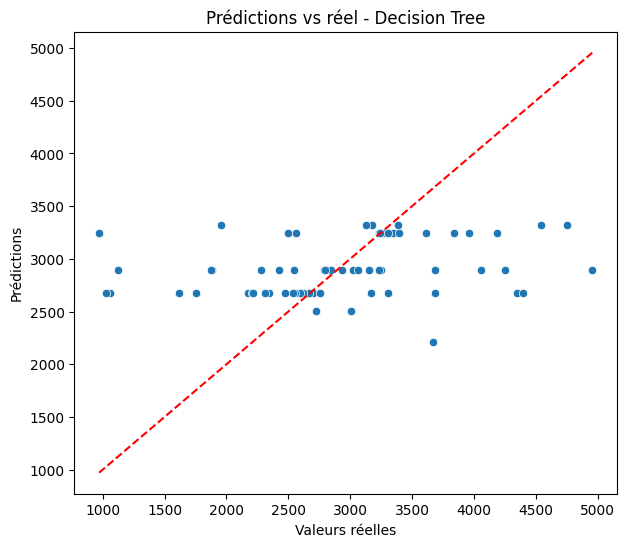

/tmp/ipykernel_37934/499379352.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")


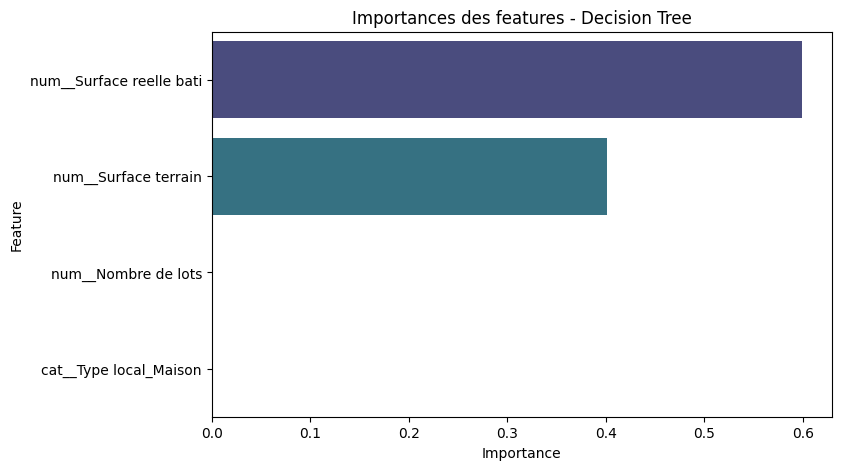

In [13]:
target = "prix_m2"
# Lancement de l'entraînement et sauvegarde pour les maisons
print("### Modèles pour maisons ###")

best_name_maison, best_pipeline_maison, best_result_maison = run_all_models(df_maisons, target, title="Modèles - Maisons")

### 11. Application aux **appartements**

On applique maintenant `run_all_models` sur le dataset des **appartements**.

Objectifs :
- Évaluer les performances des modèles sur ce segment.
- Identifier le modèle le plus performant.
- Stocker ce pipeline dans `best_pipelines_apparts`.


### Modèles pour appartements ###
Linear Regression: MAE=845.04, RMSE=1114.40, R2=0.077
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Decision Tree: MAE=839.31, RMSE=1097.31, R2=0.105
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Random Forest: MAE=847.81, RMSE=1118.36, R2=0.071
Fitting 5 folds for each of 24 candidates, totalling 120 fits
XGBoost: MAE=795.76, RMSE=1079.11, R2=0.135

➡️ Meilleur modèle : XGBoost


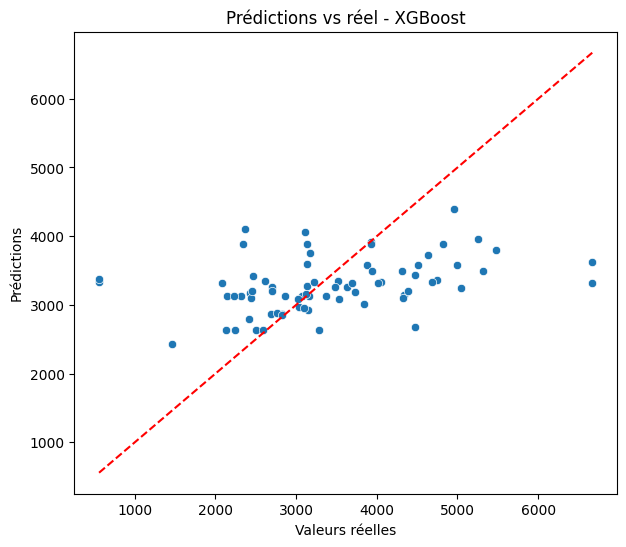

/tmp/ipykernel_37934/499379352.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")


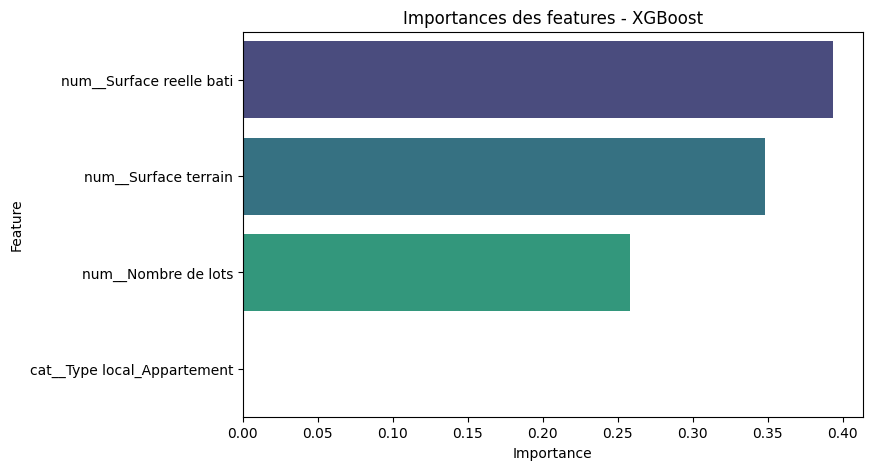

In [14]:
# Lancement de l'entraînement et sauvegarde pour les appartements
print("\n### Modèles pour appartements ###")

best_name_appart, best_pipeline_appart, best_result_appart = run_all_models(df_apparts, target, title="Modèles - Appartements")

### 12. Fonction `save_models` : sauvegarde des meilleurs modèles

La fonction `save_models` permet de sauvegarder **les meilleurs modèles entraînés** dans des fichiers `.pkl`.

#### Fonctionnement :

- **Entrées** :
    - `best_pipelines` : dictionnaire contenant les meilleurs pipelines (modèle + preprocessing).
    - `prefix` : préfixe utilisé pour nommer les fichiers (ex: `maisons`, `apparts`).
        
- **Pour chaque pipeline** :
    - Le nom du modèle est formaté pour être compatible avec un nom de fichier (`espace → _`, `+ → plus`, etc.).
    - Le pipeline est sauvegardé grâce à `joblib` dans un fichier `.pkl`.
    - Un message de confirmation est affiché.
> Cela permet de **réutiliser facilement** les modèles sans les réentraîner, notamment dans une API.


In [15]:
def save_best_model(best_model_pipeline, model_name, prefix="best_model"):
    """
    Sauvegarde le pipeline du meilleur modèle dans un fichier au format pickle.

    Parameters:
    ----------
    best_model_pipeline : sklearn.pipeline.Pipeline
        Le pipeline du modèle à sauvegarder, incluant le prétraitement et le modèle 
        entraîné.

    model_name : str
        Le nom du modèle, utilisé pour nommer le fichier de sauvegarde. Les espaces 
        dans le nom seront remplacés par des underscores et le nom sera converti 
        en minuscules.

    prefix : str, optional
        Préfixe à utiliser pour le nom du fichier de sauvegarde. Par défaut, il est 
        défini sur "best_model".

    Returns:
    -------
    None
        La fonction ne retourne rien, mais elle crée un fichier de sauvegarde du 
        modèle dans le répertoire "../models".

    Notes:
    -----
    - La fonction crée le répertoire "../models" s'il n'existe pas déjà.
    - Le fichier est sauvegardé avec l'extension .pkl, ce qui est standard pour 
      les fichiers pickle en Python.
    - Un message de confirmation est affiché dans la console indiquant le chemin 
      du fichier sauvegardé.
    """
    os.makedirs("../models", exist_ok=True)
    filename = f"{prefix}_{model_name.replace(' ', '_').lower()}.pkl"
    filepath = os.path.join("../models", filename)
    joblib.dump(best_model_pipeline, filepath)
    print(f"✅ Modèle sauvegardé dans {filepath}")


## 13 Sauvegarde des meilleurs modèles entraînés

Après l'entraînement, nous sauvegardons les **meilleurs modèles** sélectionnés pour chaque type de logement :

- maison
- appartement

Cela produit des fichiers du type :
- `maison_decision_tree.pkl`
- `appartement_xgboost.pkl`
    
> Ces fichiers pourront ensuite être rechargés facilement à l’aide de `joblib.load()`, par exemple pour faire de la prédiction via une API FastAPI.

In [16]:
# Run pour df_maisons
print("=== Maisons ===")
save_best_model(best_pipeline_maison, best_name_maison, prefix="maison")

# Run pour df_appartements
print("\n=== Appartements ===")
save_best_model(best_pipeline_appart, best_name_appart, prefix="appartement")

=== Maisons ===
✅ Modèle sauvegardé dans ../models/maison_decision_tree.pkl

=== Appartements ===
✅ Modèle sauvegardé dans ../models/appartement_xgboost.pkl
